# Access SWOT L2 Oceanography Data in AWS Cloud - Unsmoothed Data (250 m)

#### Code from https://podaac.github.io/tutorials/notebooks/datasets/DirectCloud_Access_SWOT_Oceanography.html

And modified code from S Fournier

In [ ]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:40515")
client

In [ ]:
import time
import xarray as xr
import numpy as np
import pandas as pd
import s3fs
import cartopy.crs as ccrs
from matplotlib import pyplot as plt
import cartopy
import cartopy.feature as cfeature
import earthaccess
from earthaccess import Auth, DataCollections, DataGranules, Store
%matplotlib inline

In [ ]:
auth = earthaccess.login()

## Access SWOT Level 2 KaRIn Low Rate Sea Surface Height Data Product Files on cloud

Set lat/lon bounds of data

In [ ]:
lonmin = -58
lonmax = -40
latmin = 50
latmax = 65

Earlier version of SWOT data - Version C (2.0)

In [ ]:
#retrieves granule from the days we want
#Version C (2.0): old version

#Basic: 2km
#Unsmoothed: 250m but separated between left and right swath (2 groups)
#Expert: just contains many many variables

#karin_results = earthaccess.search_data(short_name = 'SWOT_L2_LR_SSH_2.0',temporal = ("2024-10-01", "2024-10-11"),
    #bounding_box = (lonmin,latmin,lonmax,latmax),
    #granule_name = '*Basic*')

In [ ]:
#retrieves granule from the day we want
#Version D: new version

#Basic: 2km
#Unsmoothed: 250m but separated between left and right swath (2 groups)
#Expert: just contains many many variables

karin_results_unsmoothed = earthaccess.search_data(short_name = 'SWOT_L2_LR_SSH_D',
                                              temporal = ("2024-06-01", "2024-06-11"),
                                              bounding_box = (lonmin,latmin,lonmax,latmax),
                                              granule_name = '*Unsmoothed*')

Note: THe bounding box filters which granules are returned, i.e. it only returns files that intersect that bounding box, but the data within each granule may still extend outside it

In [ ]:
#for the unsmoothed, there are 2 groups left and right
#there are also other dimensions that have different size according to files so we drop it
def drop_doppler_vars(ds):
    bad_vars = [
        v for v in ds.data_vars
        if "num_doppler_miti_lines" in ds[v].dims
    ]
    ds = ds.drop_vars(bad_vars)
    return ds.drop_dims("num_doppler_miti_lines", errors="ignore")

In [ ]:
#opens granules and load into xarray dataset
ds_unsmoothed_l = xr.open_mfdataset(earthaccess.open(karin_results_unsmoothed), group='left', combine='nested', concat_dim="num_lines", decode_times=True, 
    preprocess=drop_doppler_vars, engine='h5netcdf')
ds_unsmoothed_l

In [ ]:
#opens granules and load into xarray dataset
ds_unsmoothed_r = xr.open_mfdataset(earthaccess.open(karin_results_unsmoothed), group='right', combine='nested', concat_dim="num_lines", decode_times=True, 
                                    preprocess=drop_doppler_vars, engine='h5netcdf')
ds_unsmoothed_r

## Cross Over Calibration and Corrections

In [ ]:
ds_unsmoothed_l['ssha_karin_2_corrected'] = ds_unsmoothed_l.ssha_karin_2 + ds_unsmoothed_l.height_cor_xover
ds_unsmoothed_l.ssha_karin_2_corrected

ds_unsmoothed_r['ssha_karin_2_corrected'] = ds_unsmoothed_r.ssha_karin_2 + ds_unsmoothed_r.height_cor_xover
ds_unsmoothed_r.ssha_karin_2_corrected

In [ ]:
#no rain flag in unsmoothed
flag_masks = [1,2,4,8,16,64,128,256,1024,2048,4096,8192,32768,65536,131072,262144,524288,16777216,33554432,67108864,536870912,1073741824,2147483648]
qual = ds_unsmoothed_l.ssha_karin_2_qual.astype("uint32")
bad_mask = xr.zeros_like(qual, dtype=bool)
for f in flag_masks:
    bad_mask = bad_mask | ((qual & np.uint32(f)) != 0)

good = (~bad_mask)
ds_unsmoothed_l['ssha_karin_2_corrected'] = ds_unsmoothed_l.ssha_karin_2_corrected.where(good)

qual = ds_unsmoothed_r.ssha_karin_2_qual.astype("uint32")
bad_mask = xr.zeros_like(qual, dtype=bool)
for f in flag_masks:
    bad_mask = bad_mask | ((qual & np.uint32(f)) != 0)

good = (~bad_mask)
ds_unsmoothed_r['ssha_karin_2_corrected'] = ds_unsmoothed_r.ssha_karin_2_corrected.where(good)

## Plot

In [ ]:
ssha_corrected_l = ds_unsmoothed_l.ssha_karin_2_corrected
ssha_corrected_r = ds_unsmoothed_r.ssha_karin_2_corrected

In [ ]:
mask_l = (
    (ssha_corrected_l.latitude >= 40) & (ssha_corrected_l.latitude <= 80) &
    (ssha_corrected_l.longitude >= 280) & (ssha_corrected_l.longitude <= 320)
).compute()

mask_r = (
    (ssha_corrected_r.latitude >= 40) & (ssha_corrected_r.latitude <= 80) &
    (ssha_corrected_r.longitude >= 280) & (ssha_corrected_r.longitude <= 320)
).compute()

ssha_greenland_l = ssha_corrected_l.where(mask_l, drop=True).load()
ssha_greenland_r = ssha_corrected_r.where(mask_r, drop=True).load()

In [ ]:
ssha_greenland_l

In [ ]:
#Issue: 
#pcolormesh doesn't take masked array nor Nans in lat/lon so we are fixing that by replacing Nans in lat/lon by 
#neighbooring values and put corresponding ssh at Nans but we have to have different cases in case Nans are on the side 
#of the array or the whole row/column
def prep_swot_for_pcolormesh(lon, lat, ssh):
    """
    Prepare raw SWOT swath arrays for pcolormesh plotting in Matplotlib 3.8+.

    Parameters
    ----------
    lon : np.ndarray
        2D longitude array (along-track × cross-track)
    lat : np.ndarray
        2D latitude array (along-track × cross-track)
    ssh : np.ndarray
        2D SSH array (along-track × cross-track)

    Returns
    -------
    lon2, lat2, ssh2 : np.ndarray
        Arrays ready for pcolormesh:
        - lon2, lat2: finite everywhere, degenerate quads at gaps
        - ssh2: NaN where data is invalid
    """
    # Step 0: convert to plain numpy arrays
    lon = np.asarray(lon)
    lat = np.asarray(lat)
    ssh = np.asarray(ssh)

    # Step 1: compute validity mask
    valid = np.isfinite(lon) & np.isfinite(lat) & np.isfinite(ssh)
    bad = ~valid

    # Step 2: copy arrays for plotting
    lon2 = lon.copy()
    lat2 = lat.copy()

    # Step 3: detect large jumps (swath edges, orbit gaps)
    jump = np.zeros_like(valid, dtype=bool)
    # cross-track direction
    jump[:, 1:] |= (np.abs(np.diff(lon, axis=1)) > 2.0) | (np.abs(np.diff(lat, axis=1)) > 2.0)
    # along-track direction
    jump[1:, :] |= (np.abs(np.diff(lon, axis=0)) > 2.0) | (np.abs(np.diff(lat, axis=0)) > 2.0)
    bad |= jump

    # Step 4: collapse bad points onto left neighbor (degenerate quads)
    lon2[bad] = np.roll(lon2, 1, axis=1)[bad]
    lat2[bad] = np.roll(lat2, 1, axis=1)[bad]

    # Step 5: mask SSH where bad
    ssh2 = np.where(~bad, ssh, np.nan)

    # Step 6: fill any remaining NaNs in lon/lat with nearest neighbor
    def fill_nan_geometry_only(arr):
        out = arr.copy()
        # Left → right
        for j in range(1, out.shape[1]):
            mask = ~np.isfinite(out[:, j])
            out[mask, j] = out[mask, j - 1]
        # Right → left
        for j in range(out.shape[1] - 2, -1, -1):
            mask = ~np.isfinite(out[:, j])
            out[mask, j] = out[mask, j + 1]
        # Top → bottom
        for i in range(1, out.shape[0]):
            mask = ~np.isfinite(out[i, :])
            out[i, mask] = out[i - 1, mask]
        # Bottom → top
        for i in range(out.shape[0] - 2, -1, -1):
            mask = ~np.isfinite(out[i, :])
            out[i, mask] = out[i + 1, mask]
        return out

    lon2 = fill_nan_geometry_only(lon2)
    lat2 = fill_nan_geometry_only(lat2)

    return lon2, lat2, ssh2

In [ ]:
time_vals = pd.to_datetime(ds_basic.time.values)
time_vals = time_vals[~pd.isnull(time_vals)]
time_start = time_vals[0]
time_end = time_vals[-1]
title_time = f"{time_start.strftime('%m-%d-%Y')} to {time_end.strftime('%m-%d-%Y')}"

In [ ]:
time_start

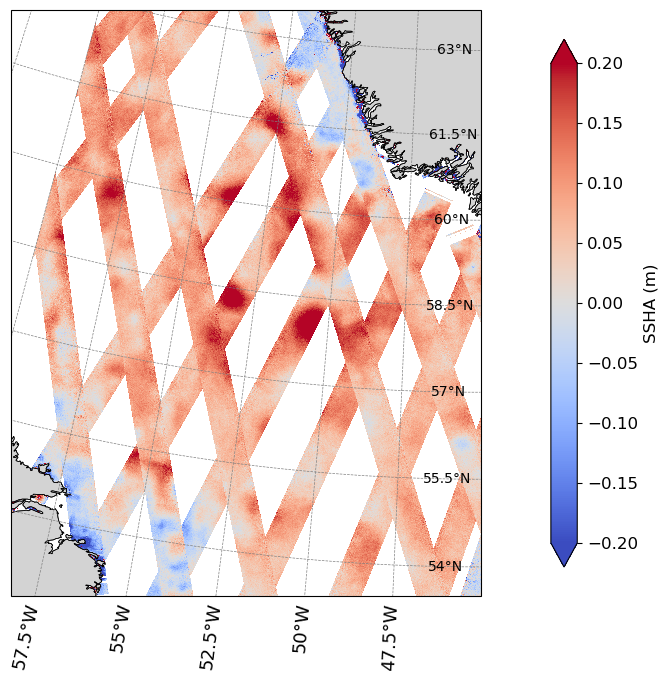

In [35]:
plt.rcParams['font.size'] = 13
fig = plt.figure(figsize=(10, 7))
map_proj = ccrs.NorthPolarStereo(central_longitude=-45)
ax = fig.add_subplot(1, 1, 1, projection=map_proj)
ax.set_extent([-58.5, -45, 53.5, 63], crs=ccrs.PlateCarree())

for feature, kwargs in [
    ('land', dict(facecolor='lightgray', edgecolor='black')),
    ('coastline', dict(facecolor='none', edgecolor='black')),
]:
    ax.add_feature(cfeature.NaturalEarthFeature('physical', feature, '10m', **kwargs), linewidth=0.5)

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.left_labels = True
gl.bottom_labels = True
gl.ylabel_style = {'size': 10, 'rotation': 0}

# --- Prepare arrays for pcolormesh ---
lon2, lat2, ssh2 = prep_swot_for_pcolormesh(
    ssha_greenland_l["longitude"].values,
    ssha_greenland_l["latitude"].values,
    ssha_greenland_l.values,
)

pp = ax.pcolormesh(
    lon2, lat2, ssh2,
    transform=ccrs.PlateCarree(),
    vmin=-0.2, vmax=0.2, cmap="coolwarm",
)

cbar = plt.colorbar(pp, ax=ax, orientation="vertical", extend='both', fraction=0.03, pad=0.08)
cbar.set_label("SSHA (m)", fontsize=12)
cbar.ax.tick_params(labelsize=12)
plt.title(f'SWOT SSHA Unsmoothed (500 m)\nCorrected & Flagged\n{title_time}')
plt.tight_layout()
plt.show()